# SIRI-ET Compare
This Jupyter Notebook compares the data quality of DELFI SIRI-ET stream with the original communication logs of an ITCS of IVU. It requires two input files:
- `data/itcs.log` The communication logs of the IVU ITCS
- `data/siriet.xml` The SIRI-ET dump of DELFI

## 1. Step: Extraction of ITCS Data
The ITCS log contains mixed text block logs and XML dumps of the VDV454-AUS data. The extraction block parses the XML contents and builds a dict in following structure:

```python
{
    'JourneyRef': [
        datetime(...),
        datetime(...),
        datetime(...),
        ...
    ]
}
```

This structure contains each journey and all timestamps, when data have been delivered for this journey.

In [8]:
from __future__ import annotations

from collections import defaultdict
from datetime import datetime
from typing import DefaultDict
from xml.etree import ElementTree as ET


# Result structure:
# {
#     "FahrtBezeichner": [datetime(...), datetime(...)]
# }
trip_timestamps: DefaultDict[str, list[datetime]] = defaultdict(list)


def process_xml(xml_text: str) -> None:
    """Extract timestamps and trip identifiers from a single XML block."""

    try:
        root: ET.Element = ET.fromstring(xml_text)
    except ET.ParseError:
        # Ignore malformed XML blocks
        return

    confirmation: ET.Element | None = root.find("./Bestaetigung")
    if confirmation is None:
        return

    timestamp_text: str | None = confirmation.attrib.get("Zst")
    if timestamp_text is None:
        return

    timestamp: datetime = datetime.fromisoformat(timestamp_text)

    # Only process IstFahrt elements.
    # SollFahrt elements are intentionally ignored.
    for istfahrt in root.iter("IstFahrt"):
        trip_identifier: ET.Element | None = istfahrt.find(
            "./FahrtRef/FahrtID/FahrtBezeichner"
        )

        if trip_identifier is None or not trip_identifier.text:
            continue

        trip_timestamps[trip_identifier.text.strip()].append(timestamp)


xml_lines: list[str] = []
collecting_xml: bool = False

with open("data/itcs.log", encoding="ISO-8859-1") as log_file:
    for line in log_file:
        xml_start: int = line.find("<?xml")

        # Start of a new XML block
        if xml_start >= 0:
            if xml_lines:
                process_xml("".join(xml_lines))

            xml_lines = [line[xml_start:]]
            collecting_xml = True
            continue

        if collecting_xml:
            # Detect the beginning of the next log entry
            is_log_line: bool = (
                len(line) >= 23
                and line[4] == "-"
                and line[7] == "-"
                and line[10] == " "
            )

            if is_log_line:
                process_xml("".join(xml_lines))
                xml_lines = []
                collecting_xml = False
            else:
                xml_lines.append(line)

# Process final XML block
if xml_lines:
    process_xml("".join(xml_lines))

# Ensure chronological ordering
for timestamps in trip_timestamps.values():
    timestamps.sort()

trip_timestamps = dict(trip_timestamps)

print(f"Number of unique trips: {len(trip_timestamps)}")
print(
    f"Number of timestamp records: "
    f"{sum(len(timestamps) for timestamps in trip_timestamps.values())}"
)

Number of unique trips: 2087
Number of timestamp records: 24869


## 2. Step: Extraction of SIRI-ET Data
The SIRI-ET dumps contain a SIRI ServiceDelivery object. The extraction block parses the XMLs and extracts for each JourneyRef the RecordedAt timestamp into a structure like that:

```python
{
    'JourneyRef': {
        'response_timestamp': datetime(...),'
        'recorded_at': datetime(...)
    }        
    ...
}
```
The `recorded_at` is the timestamp when the message from the ITCS has arrived at the SIRI-ET broker. The `response_timestamp` represents the timestamp, when the updates became published in the SIRI-ET data.

As we're looking only at the realtime updates here, only those timestamps of trips which are currently really running are considered. Old journey which still are present in the SIRI-ET data are discarded.

In [9]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import DefaultDict
from xml.etree.ElementTree import iterparse


@dataclass(slots=True)
class JourneyObservation:
    response_timestamp: datetime
    recorded_at: datetime


ACTIVE_JOURNEY_BUFFER = timedelta(minutes=1)


def parse_datetime(value: str) -> datetime:
    """Parse an ISO-8601 timestamp."""
    return datetime.fromisoformat(
        value.strip().replace("Z", "+00:00")
    )


def strip_namespace(tag: str) -> str:
    """Remove XML namespace from a tag name."""
    return tag.split("}", 1)[-1]


# Result structure:
#
# {
#     VehicleJourneyRef: [
#         JourneyObservation(...),
#         JourneyObservation(...),
#     ]
# }
journey_observations: DefaultDict[
    str,
    list[JourneyObservation],
] = defaultdict(list)


siriet_directory = Path("data/siriet")


for xml_file in sorted(siriet_directory.iterdir()):

    if not xml_file.is_file():
        continue

    response_timestamp: datetime | None = None

    for _, element in iterparse(
        xml_file,
        events=("end",),
    ):
        tag = strip_namespace(element.tag)

        # --------------------------------------------------
        # File-level ResponseTimestamp
        # --------------------------------------------------

        if (
            response_timestamp is None
            and tag == "ResponseTimestamp"
            and element.text
        ):
            response_timestamp = parse_datetime(
                element.text
            )

        # --------------------------------------------------
        # EstimatedVehicleJourney
        # --------------------------------------------------

        if tag != "EstimatedVehicleJourney":
            continue

        recorded_at: datetime | None = None
        vehicle_journey_ref: str | None = None

        departure_candidates: list[datetime] = []
        arrival_candidates: list[datetime] = []

        for child in element.iter():

            child_tag = strip_namespace(child.tag)

            # ----------------------------------------------
            # Observation timestamp
            # ----------------------------------------------

            if (
                child_tag == "RecordedAtTime"
                and child.text
                and recorded_at is None
            ):
                recorded_at = parse_datetime(
                    child.text
                )

            # ----------------------------------------------
            # Journey identifier
            # ----------------------------------------------

            elif (
                child_tag == "VehicleJourneyRef"
                and child.text
            ):
                vehicle_journey_ref = (
                    child.text.strip()
                )

            # ----------------------------------------------
            # Journey timing
            # ----------------------------------------------

            elif (
                child_tag == "EstimatedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "EstimatedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

        # --------------------------------------------------
        # Basic validation
        # --------------------------------------------------

        if (
            response_timestamp is None
            or recorded_at is None
            or vehicle_journey_ref is None
        ):
            element.clear()
            continue

        if not departure_candidates:
            element.clear()
            continue

        journey_start = min(
            departure_candidates
        )

        # Prefer arrivals for end time.
        # If no arrival exists, use the last departure.
        if arrival_candidates:
            journey_end = max(
                arrival_candidates
            )
        else:
            journey_end = max(
                departure_candidates
            )

        # --------------------------------------------------
        # Keep only observations that were taken while
        # the journey was actually active.
        # --------------------------------------------------

        if not (
            journey_start - ACTIVE_JOURNEY_BUFFER
            <= response_timestamp
            <= journey_end + ACTIVE_JOURNEY_BUFFER
        ):
            element.clear()
            continue

        journey_observations[
            vehicle_journey_ref
        ].append(
            JourneyObservation(
                response_timestamp=response_timestamp,
                recorded_at=recorded_at,
            )
        )

        # Release memory while streaming
        element.clear()


# --------------------------------------------------
# Sort observations chronologically
# --------------------------------------------------

for observations in journey_observations.values():

    observations.sort(
        key=lambda observation:
        observation.response_timestamp
    )


journey_observations = dict(
    journey_observations
)


# --------------------------------------------------
# Existing ITCS matching functionality
# --------------------------------------------------

matched_itcs_journeys: set[str] = set()

for siri_journey in journey_observations:

    for itcs_journey in trip_timestamps:

        if siri_journey.startswith(
            itcs_journey
        ):
            matched_itcs_journeys.add(
                itcs_journey
            )
            break


print(
    f"Number of unique SIRI journeys: "
    f"{len(journey_observations)}"
)

print(
    f"Number of journeys from ITCS: "
    f"{len(matched_itcs_journeys)}"
)

print(
    f"Number of observations: "
    f"{sum(len(v) for v in journey_observations.values())}"
)

Number of unique SIRI journeys: 957
Number of journeys from ITCS: 30
Number of observations: 957


## 3. Step: Metrics
Out of the collected data, following metrics are built:
- Assimilation Latency: This is the time which an ITCS update takes to be recorded by the SIRI-ET sink. It is not the time when the update becomes visible!
- Snapshot Staleness: This is the 'age of the data' in a SIRI-ET snapshot.
- Publication Latency: This is the time range which an ITCS updates takes to be exposed in SIRI-ET data.
- Future ITCS Updates: This is the number of updates the ITCS has sent after the last publication of a journey.

---- Summary ----
Matched observations: 30

Assimilation Latency
Mean   : 3.71 s
Median : 3.65 s
P90    : 3.97 s
P95    : 3.97 s
P99    : 3.97 s
Max    : 4.18 s

Snapshot Staleness
Mean   : 3070.76 s
Median : 341.62 s
P90    : 9236.55 s
P95    : 9296.54 s
P99    : 10196.49 s
Max    : 11096.51 s

Publication Latency
Mean   : 3034.46 s
Median : 345.20 s
P90    : 9210.20 s
P95    : 9210.20 s
P99    : 9300.20 s
Max    : 11100.20 s

Future ITCS Updates
Mean   : 1.13
Max    : 6


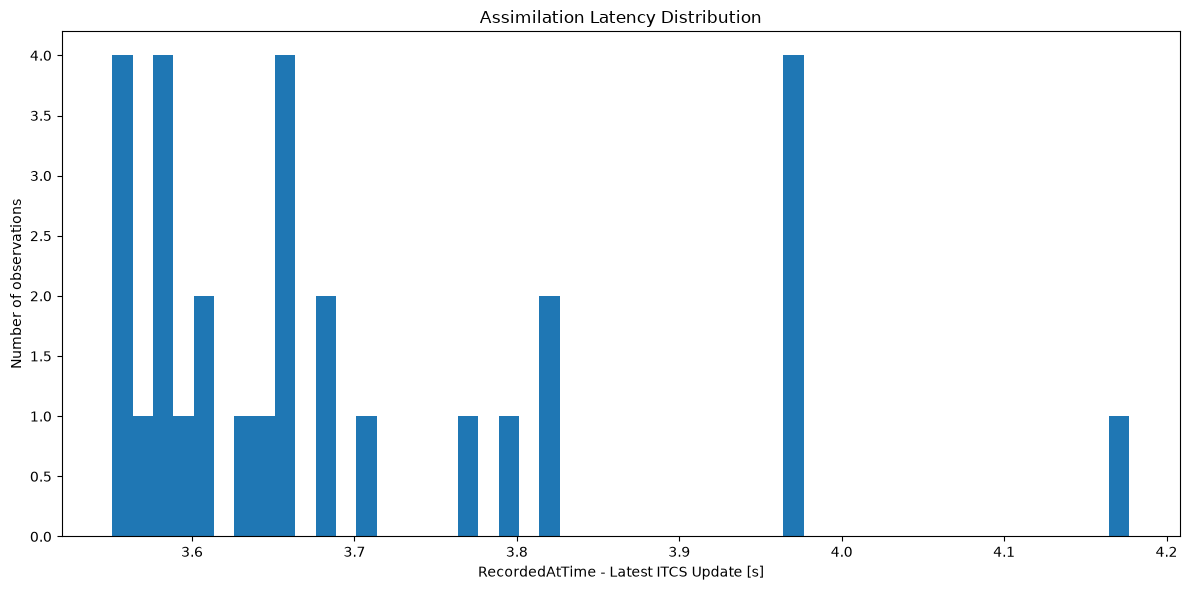

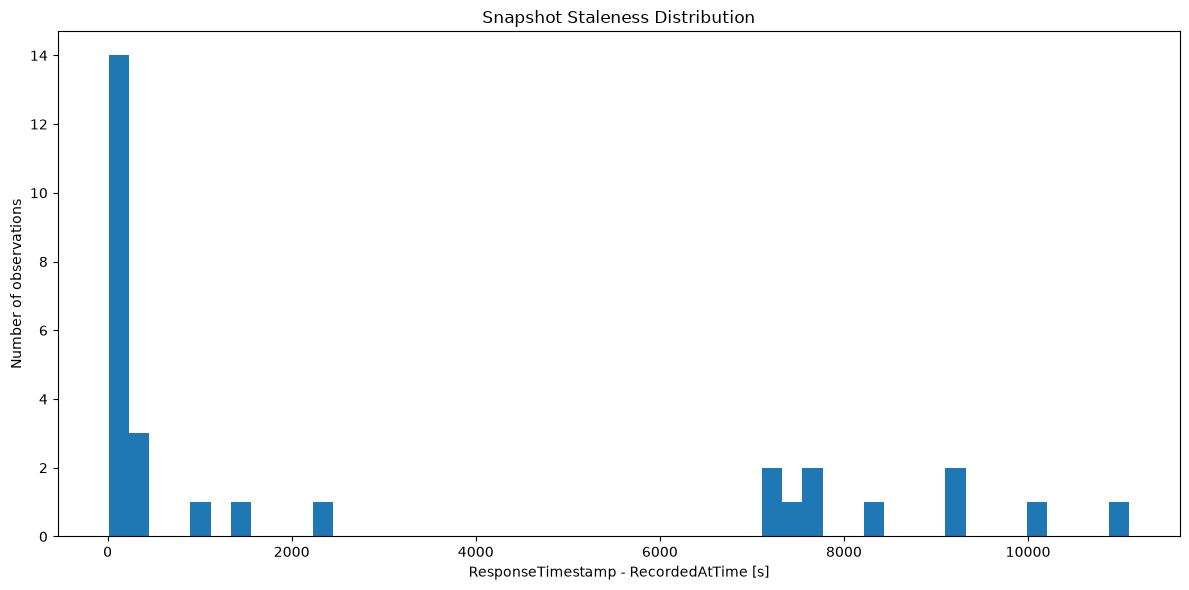

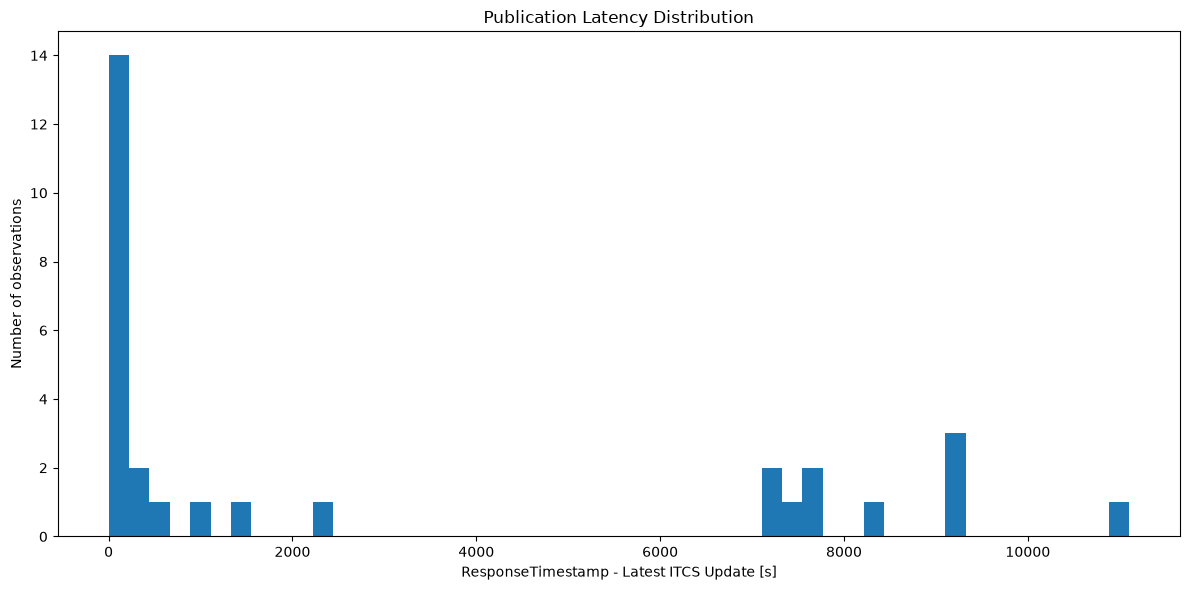

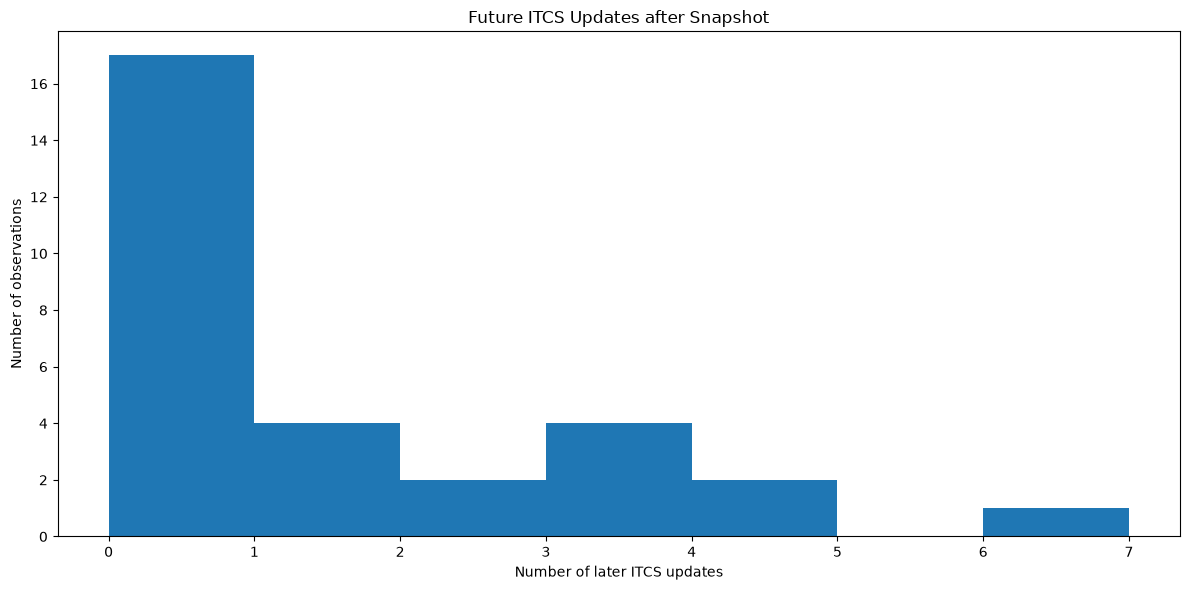

In [10]:
from __future__ import annotations

from statistics import mean
from typing import List

import matplotlib.pyplot as plt


# --------------------------------------------------
# Inputs
#
# trip_timestamps:
#   dict[str, list[datetime]]
#
# journey_observations:
#   dict[str, list[JourneyObservation]]
# --------------------------------------------------


assimilation_latency_seconds: List[float] = []
snapshot_staleness_seconds: List[float] = []
publication_latency_seconds: List[float] = []
updates_after_snapshot: List[int] = []

matched_observations: int = 0


def percentile(
    values: list[float],
    p: float,
) -> float:
    if not values:
        raise ValueError("Cannot calculate percentile of empty list")

    index = int((len(values) - 1) * p)
    return values[index]


for siri_journey, observations in journey_observations.items():

    matching_itcs_journey: str | None = next(
        (
            itcs_journey
            for itcs_journey in trip_timestamps
            if siri_journey.startswith(itcs_journey)
        ),
        None,
    )

    if matching_itcs_journey is None:
        continue

    itcs_updates = trip_timestamps[matching_itcs_journey]

    for observation in observations:

        matched_observations += 1

        # --------------------------------------------------
        # Assimilation Latency
        #
        # RecordedAtTime
        # minus
        # latest ITCS update <= RecordedAtTime
        # --------------------------------------------------

        latest_itcs_before_recorded = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.recorded_at
            ),
            default=None,
        )

        if latest_itcs_before_recorded is not None:

            assimilation_latency = (
                observation.recorded_at
                - latest_itcs_before_recorded
            ).total_seconds()

            assimilation_latency_seconds.append(
                assimilation_latency
            )

        # --------------------------------------------------
        # Snapshot Staleness
        #
        # ResponseTimestamp
        # minus
        # RecordedAtTime
        # --------------------------------------------------

        staleness = (
            observation.response_timestamp
            - observation.recorded_at
        ).total_seconds()

        snapshot_staleness_seconds.append(
            staleness
        )

        # --------------------------------------------------
        # Publication Latency
        #
        # ResponseTimestamp
        # minus
        # latest ITCS update <= ResponseTimestamp
        # --------------------------------------------------

        latest_itcs_before_response = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.response_timestamp
            ),
            default=None,
        )

        if latest_itcs_before_response is not None:

            publication_latency = (
                observation.response_timestamp
                - latest_itcs_before_response
            ).total_seconds()

            publication_latency_seconds.append(
                publication_latency
            )

        # --------------------------------------------------
        # Future ITCS updates
        # --------------------------------------------------

        count_after = sum(
            1
            for timestamp in itcs_updates
            if timestamp > observation.response_timestamp
        )

        updates_after_snapshot.append(
            count_after
        )


# --------------------------------------------------
# Sort for percentile calculations
# --------------------------------------------------

assimilation_latency_seconds.sort()
snapshot_staleness_seconds.sort()
publication_latency_seconds.sort()


# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------

print("---- Summary ----")
print(f"Matched observations: {matched_observations}")


def print_metric_summary(
    name: str,
    values: list[float],
) -> None:

    if not values:
        return

    print()
    print(name)

    print(f"Mean   : {mean(values):.2f} s")
    print(f"Median : {percentile(values, 0.50):.2f} s")
    print(f"P90    : {percentile(values, 0.90):.2f} s")
    print(f"P95    : {percentile(values, 0.95):.2f} s")
    print(f"P99    : {percentile(values, 0.99):.2f} s")
    print(f"Max    : {max(values):.2f} s")


print_metric_summary(
    "Assimilation Latency",
    assimilation_latency_seconds,
)

print_metric_summary(
    "Snapshot Staleness",
    snapshot_staleness_seconds,
)

print_metric_summary(
    "Publication Latency",
    publication_latency_seconds,
)

if updates_after_snapshot:

    print()
    print("Future ITCS Updates")

    print(
        f"Mean   : "
        f"{mean(updates_after_snapshot):.2f}"
    )

    print(
        f"Max    : "
        f"{max(updates_after_snapshot)}"
    )


# --------------------------------------------------
# Plot 1
# Assimilation Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    assimilation_latency_seconds,
    bins=50,
)

plt.title(
    "Assimilation Latency Distribution"
)

plt.xlabel(
    "RecordedAtTime - Latest ITCS Update [s]"
)

plt.ylabel(
    "Number of observations"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2
# Snapshot Staleness
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    snapshot_staleness_seconds,
    bins=50,
)

plt.title(
    "Snapshot Staleness Distribution"
)

plt.xlabel(
    "ResponseTimestamp - RecordedAtTime [s]"
)

plt.ylabel(
    "Number of observations"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 3
# Publication Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    publication_latency_seconds,
    bins=50,
)

plt.title(
    "Publication Latency Distribution"
)

plt.xlabel(
    "ResponseTimestamp - Latest ITCS Update [s]"
)

plt.ylabel(
    "Number of observations"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 4
# Future Updates
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    updates_after_snapshot,
    bins=range(
        0,
        max(updates_after_snapshot) + 2,
    ),
)

plt.title(
    "Future ITCS Updates after Snapshot"
)

plt.xlabel(
    "Number of later ITCS updates"
)

plt.ylabel(
    "Number of observations"
)

plt.tight_layout()
plt.show()